# PROJECT SETTINGS & IMPORTS

In [1]:

import os
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# Used to create custom legends for maps
from matplotlib.lines import Line2D

# Used for statistical plots and styling
import seaborn as sns

# Used for fast nearest-neighbour distance calculations
from scipy.spatial import cKDTree

# Used for merging and splitting highway geometries
from shapely.ops import unary_union, linemerge, substring

# Used for state-level clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [93]:
# Limit OpenMP threads to reduce the common KMeans / MKL warning on Windows.
os.environ["OMP_NUM_THREADS"] = "1"

# Hide non-critical warnings so that notebook outputs remain easier to read.
warnings.filterwarnings("ignore")


In [94]:
# Apply a consistent Seaborn plotting style.
sns.set_style("whitegrid")

# Set default figure resolution and title style.
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titleweight": "bold"
})


In [95]:
# Folder containing the cleaned input datasets.
DATA = Path("../data/Cleaned datasets")

# Main output folder.
OUT = Path("../outputs")

# Create folders for charts and tables if they
# do not already exist.
(OUT / "figures").mkdir(parents=True, exist_ok=True)
(OUT / "tables").mkdir(parents=True, exist_ok=True)


In [96]:
# Projected CRS used for distance and length calculations.
# EPSG:7755 uses metres as the distance unit.
METRIC_CRS = "EPSG:7755"

# A charger within 5 km of a mapped highway is considered to be associated with that highway.
CORRIDOR_KM = 5

# Target highway segment length.
SEG_KM = 25

# A highway segment is considered a charging gap when the nearest fast charger is more than 50 km away.
GAP_KM = 50

# Ignore very short highway fragments when building continuous highway components.
MIN_COMPONENT_KM = 5

# Minimum number of car + bus EV registrations used when ranking EV-desert states.
MIN_DEMAND = 5000

# Definition of a fast charger for the main analysis. Chargers with >= 25 kW are treated as fast.
FAST_KW = 25

# False = use the power-based definition above.
# True = use the OpenChargeMap fast-charging flag instead.
USE_DATASET_FLAG = False

# Six target highways selected for detailed corridor analysis.
TARGET_HIGHWAYS = [
    "NH-44",
    "NH-48",
    "NH-16",
    "NH-66",
    "NH-544",
    "NH52"
]

# Years available in the EV registration datasets.
YEARS = [str(y) for y in range(2017, 2027)]

# Standardized state name used for Dadra and Nagar Haveli and Daman and Diu.
DNHDD = "dadra and nagar haveli and daman and diu"


In [97]:
def finish(name: str):
    """
    Save the current Matplotlib figure as a PNG
    and display it in the notebook.
    """

    # Adjust spacing so labels do not overlap.
    plt.tight_layout()

    # Save the figure inside the outputs/figures folder.
    plt.savefig(
        OUT / "figures" / f"{name}.png",
        bbox_inches="tight"
    )

    # Display the figure in the notebook.
    plt.show()

# LOAD CLEANED DATASETS

In [98]:
# Load all cleaned datasets required for the analysis.
states_gdf   = gpd.read_parquet(DATA / "states_clean.parquet")
highways_gdf = gpd.read_file(DATA / "highways_clean.geojson")
ev_all       = pd.read_csv(DATA / "Ev_registration_cleaned.csv")
ev_car       = pd.read_csv(DATA / "ev_registration_car_cleaned.csv")
ev_bus       = pd.read_csv(DATA / "ev_registration_bus_cleaned.csv")
chargers_df  = pd.read_csv(DATA / "Ev_chargers_cleaned.csv")

In [100]:
# Convert EV year column names to strings so that they match the YEARS list defined above.
for df in (ev_all, ev_car, ev_bus):
    df.columns = df.columns.astype(str)

In [101]:
# Print dataset shapes
for name, obj in [
    ("states", states_gdf),
    ("highways", highways_gdf),
    ("ev_all", ev_all),
    ("ev_car", ev_car),
    ("ev_bus", ev_bus),
    ("chargers", chargers_df),
]:
    print(f"{name:10s}", obj.shape)

states     (36, 7)
highways   (9507, 28)
ev_all     (36, 12)
ev_car     (36, 12)
ev_bus     (36, 12)
chargers   (1841, 15)


# DATA QUALITY CHECKS

In [102]:
# Add all yearly registrations and compare the result with the provided "Total" column.
# A mismatch of zero means the yearly values correctly reproduce the Total column.
for name, df in [("all", ev_all), ("car", ev_car), ("bus", ev_bus)]:
    mismatch = (df[YEARS].sum(axis=1) - df["Total"]).abs().sum()
    print(f"EV {name}: total mismatch =", mismatch)

EV all: total mismatch = 0
EV car: total mismatch = 0
EV bus: total mismatch = 0


In [103]:
# Create charger-power groups so that we can compare the dataset's fast-charging flag against actual power.
band = pd.cut(chargers_df["max_power_kw"], [-0.1, 0, 7.5, 22, 50, 1000],
              labels=["0 (missing)", "0-7.5", "7.5-22", "22-50", ">50"])
display(pd.crosstab(band, chargers_df["has_fast_charging"],
                    rownames=["max power (kW)"], colnames=["dataset flag"]))
flag = chargers_df["has_fast_charging"].astype(bool)
print(f"Flag=True but power < {FAST_KW} kW :", int((flag & (chargers_df['max_power_kw'] < FAST_KW)).sum()))
print(f"Flag=False but power >= {FAST_KW} kW:", int((~flag & (chargers_df['max_power_kw'] >= FAST_KW)).sum()))

dataset flag,False,True
max power (kW),,
0 (missing),101,0
0-7.5,211,1
7.5-22,42,5
22-50,85,763
>50,16,617


Flag=True but power < 25 kW : 53
Flag=False but power >= 25 kW: 99


In [104]:
# Check whether any charger IDs are duplicated.
print("Duplicate IDs:", chargers_df["ID"].duplicated().sum())
# Count chargers where power was recorded as zero.
print("Zero-kW chargers:", (chargers_df["max_power_kw"] == 0).sum())

Duplicate IDs: 0
Zero-kW chargers: 101


# STATE NAME NORMALIZATION

In [105]:
# Common alternative names found in different datasets.
ALIASES = {
    "orissa": "odisha",
    "uttaranchal": "uttarakhand",
    "pondicherry": "puducherry",
    "nct of delhi": "delhi",
    "delhi nct": "delhi",
    "ut of dnh and dd": DNHDD,
    "dnh and dd": DNHDD,
    "dadra and nagar haveli": DNHDD,
    "daman and diu": DNHDD,
}

In [106]:
def make_key(s: pd.Series) -> pd.Series:
    s = (
        s.astype(str)
        .str.lower()
        .str.replace("&", "and", regex=False)
        .str.replace(r"[^a-z\s]", " ", regex=True)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
        .str.replace("islands", "island", regex=False)
    )
    return s.replace(ALIASES)

In [107]:
# Create standardized keys for state boundaries.
states_gdf["state_key"] = make_key(states_gdf["state"])
for df in (ev_all, ev_car, ev_bus):
    df["state_key"] = make_key(df["State"])

key2name = states_gdf.drop_duplicates("state_key").set_index("state_key")["state"].to_dict()

In [108]:
# Compare the state keys in each EV dataset against the state boundary dataset.
for name, df in [("ev_all", ev_all), ("ev_car", ev_car), ("ev_bus", ev_bus)]:
    a = sorted(set(states_gdf.state_key) - set(df.state_key))
    b = sorted(set(df.state_key) - set(states_gdf.state_key))
    print(name, "| in map not in EV:", a, "| in EV not in map:", b)

ev_all | in map not in EV: [] | in EV not in map: []
ev_car | in map not in EV: [] | in EV not in map: []
ev_bus | in map not in EV: [] | in EV not in map: []


# CHARGERS → GEODATA & FAST DEFINITION

In [109]:
# Keep only chargers currently marked as operational.
chargers_op = chargers_df[chargers_df["is_operational"] == True].copy()
chargers_op["max_power_kw"] = chargers_op["max_power_kw"].replace(0, np.nan)

In [18]:
# Define fast chargers
if USE_DATASET_FLAG:
    chargers_op["is_fast"] = chargers_op["has_fast_charging"].astype(bool)
else:
    chargers_op["is_fast"] = chargers_op["max_power_kw"] >= FAST_KW

In [19]:
# Convert to GeoDataFrame
chargers_gdf = gpd.GeoDataFrame(
    chargers_op,
    geometry=gpd.points_from_xy(chargers_op["longitude"], chargers_op["latitude"]),
    crs="EPSG:4326"
).to_crs(METRIC_CRS)

In [20]:
# States in metric CRS
states_m = states_gdf.to_crs(METRIC_CRS)
st_small = states_m[["state_key", "geometry"]].rename(columns={"state_key": "state_geo"})

In [21]:
# Spatial join: assign chargers to states
chargers_join = gpd.sjoin(chargers_gdf, st_small, how="left", predicate="within")
chargers_join = chargers_join[~chargers_join.index.duplicated()].drop(columns="index_right")

In [22]:
# Handle missing state assignments (snap to nearest within 25 km)
miss = chargers_join["state_geo"].isna()
if miss.any():
    fix = gpd.sjoin_nearest(
        chargers_join.loc[miss].drop(columns="state_geo"),
        st_small,
        how="left",
        max_distance=25_000
    )
    fix = fix[~fix.index.duplicated()]
    chargers_join.loc[miss, "state_geo"] = fix["state_geo"]

chargers_gdf = chargers_join.dropna(subset=["state_geo"]).copy()
chargers_gdf["state_name"] = chargers_gdf["state_geo"].map(key2name)

In [23]:
# Summary
print("Operational chargers:", len(chargers_gdf))
print(f"Fast by power rule (>= {FAST_KW} kW):", (chargers_gdf["max_power_kw"] >= FAST_KW).sum())
print("Fast by dataset flag:", chargers_gdf["has_fast_charging"].astype(bool).sum())
print("Fast chargers used in analysis:", chargers_gdf["is_fast"].sum())

Operational chargers: 1822
Fast by power rule (>= 25 kW): 1421
Fast by dataset flag: 1375
Fast chargers used in analysis: 1421


# Q1 – HOW FAST IS EV ADOPTION GROWING?

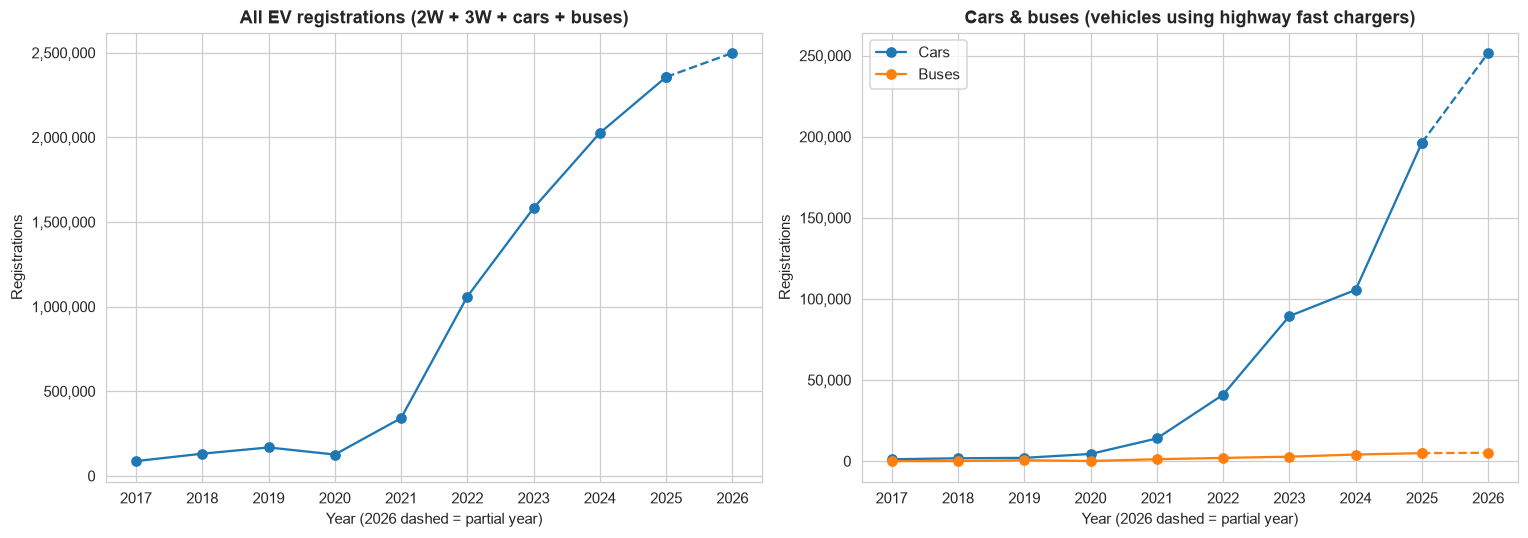

Share of cars+buses in all EV registrations: 7.0 %


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

def plot_line(ax, series, label):
    ax.plot(YEARS[:-1], series.values[:-1], marker="o", label=label)
    ax.plot(YEARS[-2:], series.values[-2:], ls="--", marker="o", color=ax.lines[-1].get_color())

# All EVs
plot_line(axes[0], ev_all[YEARS].sum(), "All EVs")
axes[0].set_title("All EV registrations (2W + 3W + cars + buses)")

# Cars & buses
plot_line(axes[1], ev_car[YEARS].sum(), "Cars")
plot_line(axes[1], ev_bus[YEARS].sum(), "Buses")
axes[1].set_title("Cars & buses (vehicles using highway fast chargers)")
axes[1].legend()

for ax in axes:
    ax.set_xlabel("Year (2026 dashed = partial year)")
    ax.set_ylabel("Registrations")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))

finish("01_ev_growth")

share_cb = (ev_car["Total"].sum() + ev_bus["Total"].sum()) / ev_all["Total"].sum() * 100
print("Share of cars+buses in all EV registrations:", round(share_cb, 1), "%")

# Q1 – WHICH STATES DRIVE THE GROWTH?

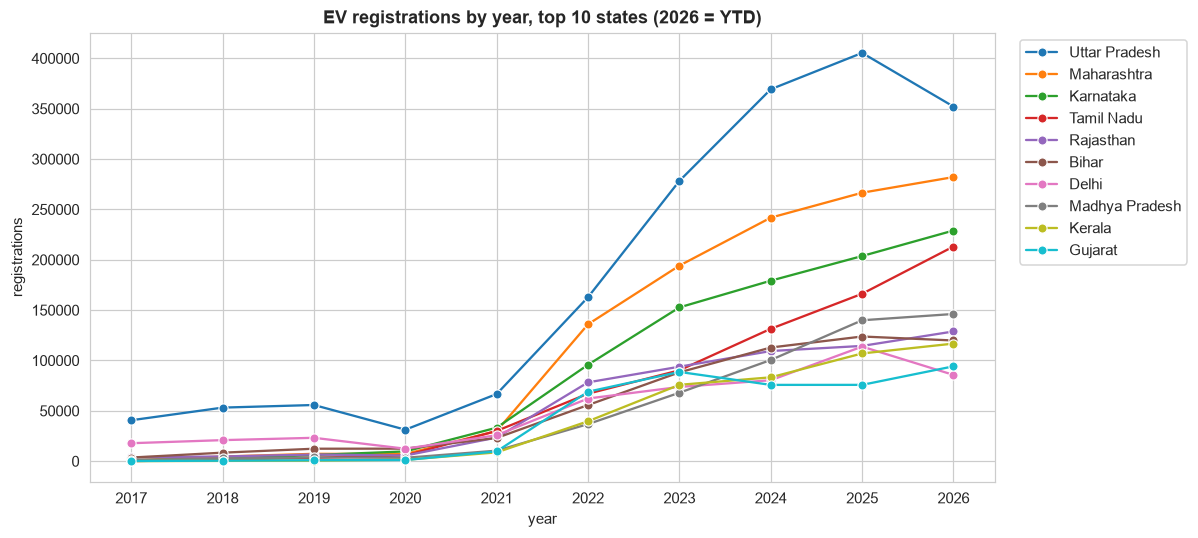

In [25]:
top10_states = ev_all.nlargest(10, "Total")
trend_data = top10_states.melt(
    id_vars="State",
    value_vars=YEARS,
    var_name="year",
    value_name="registrations"
)

plt.figure(figsize=(11, 5))
sns.lineplot(data=trend_data, x="year", y="registrations", hue="State", marker="o")
plt.title("EV registrations by year, top 10 states (2026 = YTD)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
finish("02_top10_state_trend")

# Q3 – HOW POWERFUL ARE THE CHARGERS?

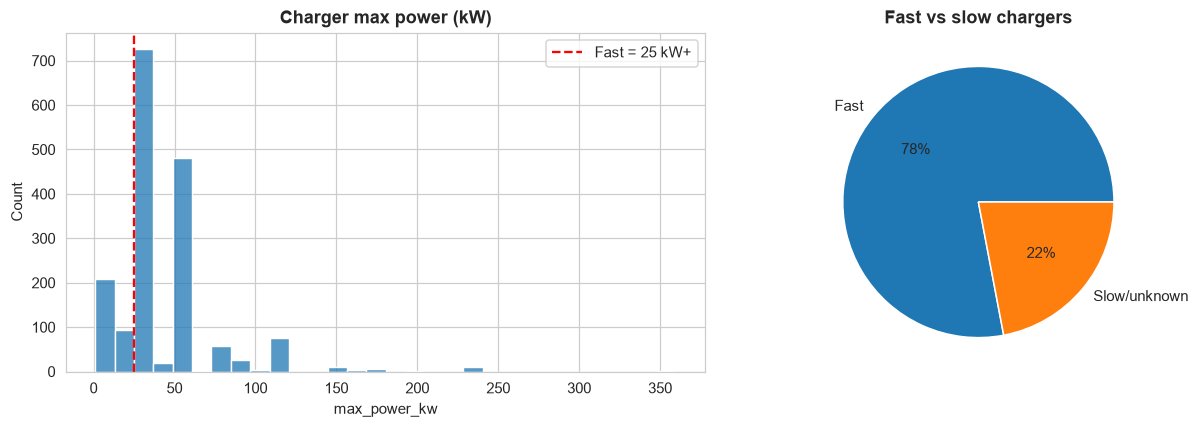

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of charger power
sns.histplot(chargers_gdf["max_power_kw"].dropna(), bins=30, ax=ax[0])
ax[0].axvline(FAST_KW, color="red", ls="--", label=f"Fast = {FAST_KW} kW+")
ax[0].legend()
ax[0].set_title("Charger max power (kW)")

# Fast vs slow pie chart
chargers_gdf["is_fast"].map({True: "Fast", False: "Slow/unknown"}).value_counts().plot.pie(
    autopct="%1.0f%%", ax=ax[1]
)
ax[1].set_ylabel("")
ax[1].set_title("Fast vs slow chargers")

finish("03_charger_power")

# Q3 – WHO RUNS THE CHARGERS?

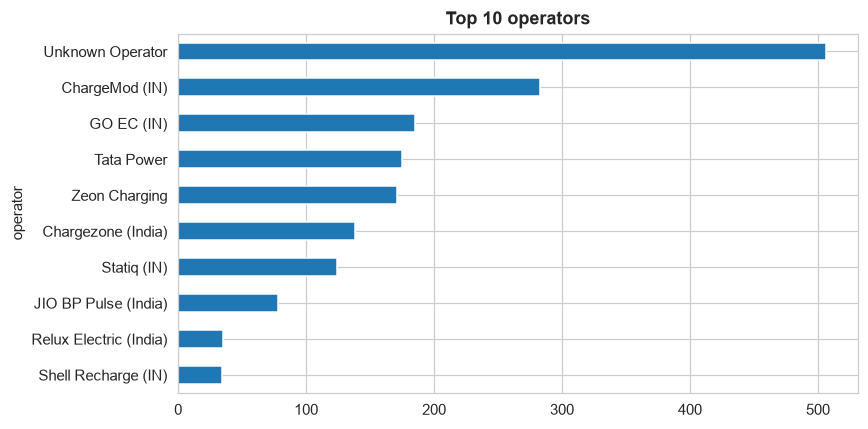

Share with 'Unknown Operator': 27.8 %


In [27]:
operators = chargers_gdf["operator"].value_counts()
operators.head(10).plot.barh(figsize=(8, 4)).invert_yaxis()
plt.title("Top 10 operators")
finish("04_top_operators")

unknown_share = round(operators.get("Unknown Operator", 0) / len(chargers_gdf) * 100, 1)
print("Share with 'Unknown Operator':", unknown_share, "%")

# Q3 – ARE CHARGERS IN EACH STATE FAST OR SLOW?

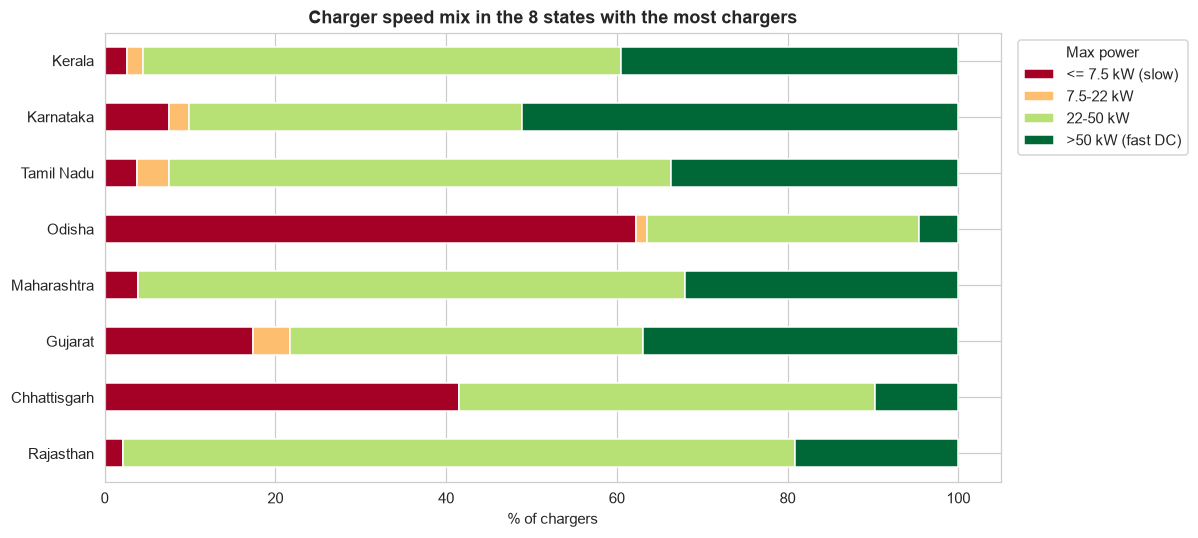

In [28]:
bins = [0, 7.5, 22, 50, 1000]
labels = ["<= 7.5 kW (slow)", "7.5-22 kW", "22-50 kW", ">50 kW (fast DC)"]

chargers_copy = chargers_gdf.copy()
chargers_copy["power_band"] = pd.cut(chargers_copy["max_power_kw"], bins=bins, labels=labels)

# Top 8 states by charger count
top_states = chargers_copy["state_name"].value_counts().head(8).index

mix = (
    chargers_copy[chargers_copy["state_name"].isin(top_states)]
    .groupby(["state_name", "power_band"])
    .size()
    .unstack(fill_value=0)
)

mix = mix.div(mix.sum(axis=1), axis=0) * 100

mix.loc[top_states[::-1]].plot(
    kind="barh", stacked=True, figsize=(11, 5), colormap="RdYlGn"
)
plt.xlabel("% of chargers")
plt.ylabel("")
plt.title("Charger speed mix in the 8 states with the most chargers")
plt.legend(title="Max power", bbox_to_anchor=(1.01, 1), loc="upper left")
finish("05_charger_speed_mix")

# STATE MASTER TABLE (Demand vs Supply)

In [29]:
# EV demand metrics
ev = ev_all[["state_key", "2021", "2025", "Total"]].rename(columns={"Total": "ev_total"})
ev["ev_cagr_21_25"] = np.where(ev["2021"] > 0, (ev["2025"] / ev["2021"]) ** (1 / 4) - 1, np.nan)
ev = ev[["state_key", "ev_total", "ev_cagr_21_25"]]
ev_c = ev_car[["state_key", "Total"]].rename(columns={"Total": "ev_cars"})
ev_b = ev_bus[["state_key", "Total"]].rename(columns={"Total": "ev_buses"})

In [30]:
# Charger supply metrics
chg = (
    chargers_gdf.groupby("state_geo")
    .agg(
        n_chargers=("ID", "count"),
        n_fast=("is_fast", "sum"),
        total_points=("total_points", "sum"),
        median_kw=("max_power_kw", "median"),
    )
    .reset_index()
    .rename(columns={"state_geo": "state_key"})
)

In [31]:
# Merge into master table
master = (
    states_gdf[["state", "state_key", "area_km2"]]
    .merge(ev, on="state_key", how="left")
    .merge(ev_c, on="state_key", how="left")
    .merge(ev_b, on="state_key", how="left")
    .merge(chg, on="state_key", how="left")
)

master[["n_chargers", "n_fast", "total_points"]] = master[["n_chargers", "n_fast", "total_points"]].fillna(0)

In [32]:
# Derived metrics
master["hw_ev"] = master["ev_cars"] + master["ev_buses"]
master["chargers_per_1000km2"] = master["n_chargers"] / master["area_km2"] * 1000
master["evs_per_charger"] = master["ev_total"] / master["n_chargers"].clip(lower=1)
master["evs_per_fast_charger"] = master["hw_ev"] / (master["n_fast"] + 1)  # avoid divide-by-zero
master["fast_per_100k_hw_ev"] = (master["n_fast"] / master["hw_ev"] * 1e5).replace([np.inf, -np.inf], np.nan)

In [33]:
# EV desert definition
med_ev, med_fc = master["hw_ev"].median(), master["n_fast"].median()
master["ev_desert"] = (master["hw_ev"] >= med_ev) & (master["n_fast"] < med_fc)

In [34]:
# Display top states by EVs per fast charger
display(
    master[["state", "ev_total", "hw_ev", "n_chargers", "n_fast", "evs_per_fast_charger", "ev_desert"]]
    .sort_values("evs_per_fast_charger", ascending=False)
    .reset_index(drop=True).head(15)
)

,state,ev_total,hw_ev,n_chargers,n_fast,evs_per_fast_charger,ev_desert
0,Telangana,357920,60455,17.0,10.0,5495.909091,False
1,Bihar,560438,4707,1.0,0.0,4707.000000,False
2,Punjab,181928,11873,2.0,2.0,3957.666667,True
3,Delhi,515897,68110,34.0,17.0,3783.888889,False
4,Chandigarh,27419,7283,1.0,1.0,3641.500000,True
5,West Bengal,341644,20032,9.0,7.0,2504.000000,False
6,Assam,384300,2385,2.0,0.0,2385.000000,False
7,Uttar Pradesh,1815492,43468,28.0,20.0,2069.904762,False
8,Maharashtra,1170473,117168,83.0,75.0,1541.684211,False
9,Madhya Pradesh,513003,16643,13.0,11.0,1386.916667,False


# Q2 – WHERE IS DEMAND HIGH BUT FAST-CHARGER SUPPLY LOW?

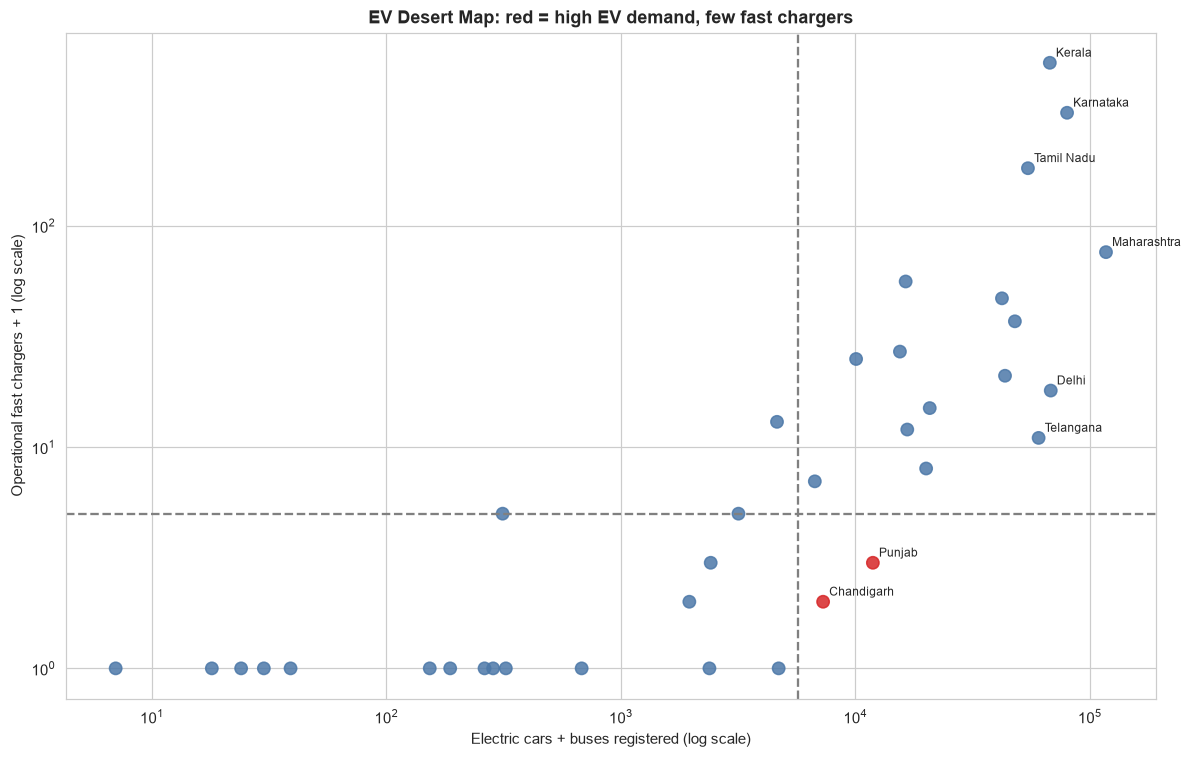

In [35]:
d = master.copy()

fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(
    d["hw_ev"].clip(lower=1),
    d["n_fast"] + 1,
    c=np.where(d["ev_desert"], "#d62728", "#4c78a8"),
    s=65,
    alpha=0.85,
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.axvline(med_ev, ls="--", c="grey")
ax.axhline(med_fc + 1, ls="--", c="grey")

# Annotate EV deserts and high-demand states
for _, r in d[d["ev_desert"] | (d["hw_ev"] >= d["hw_ev"].quantile(0.85))].iterrows():
    ax.annotate(r["state"], (max(r["hw_ev"], 1), r["n_fast"] + 1), fontsize=8, xytext=(4, 4), textcoords="offset points")

ax.set_xlabel("Electric cars + buses registered (log scale)")
ax.set_ylabel("Operational fast chargers + 1 (log scale)")
ax.set_title("EV Desert Map: red = high EV demand, few fast chargers")
finish("06_ev_desert_quadrant")

#  Q2 – TOP 12 EV DESERTS

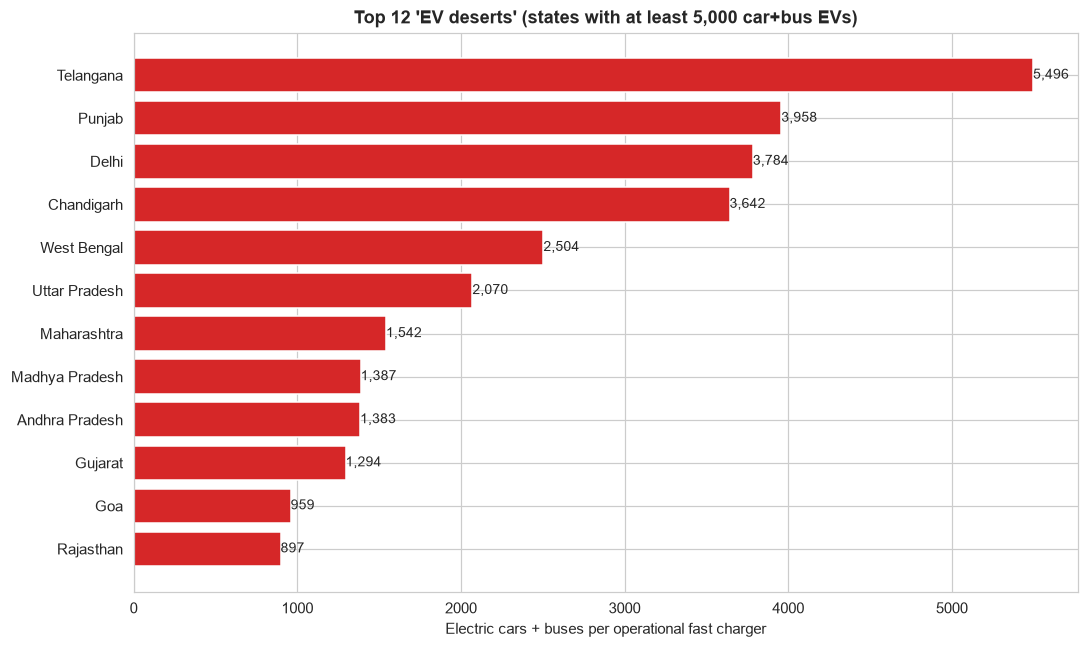

Note: OpenChargeMap is crowd-sourced; very low counts may partly reflect incomplete mapping.


In [36]:
top_ev_deserts = (
    master[master["hw_ev"] >= MIN_DEMAND]
    .nlargest(12, "evs_per_fast_charger")
    .iloc[::-1]
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_ev_deserts["state"], top_ev_deserts["evs_per_fast_charger"], color="#d62728")

for y, v in enumerate(top_ev_deserts["evs_per_fast_charger"]):
    ax.text(v, y, f"{v:,.0f}", va="center", fontsize=9)

ax.set_xlabel("Electric cars + buses per operational fast charger")
ax.set_title(f"Top 12 'EV deserts' (states with at least {MIN_DEMAND:,} car+bus EVs)")
finish("07_top_ev_deserts")

print("Note: OpenChargeMap is crowd-sourced; very low counts may partly reflect incomplete mapping.")

# NATIONAL ROAD NETWORK PREPARATION

In [37]:
hw_all = highways_gdf.copy()
if hw_all.crs is None:
    hw_all = hw_all.set_crs("EPSG:4326")

hw_all = hw_all.to_crs(METRIC_CRS)
hw_all = hw_all[hw_all.geometry.notna() & ~hw_all.geometry.is_empty][["road_name", "road_type", "geometry"]]
hw_all = hw_all.explode(index_parts=False).reset_index(drop=True)
hw_all = hw_all[hw_all.geom_type == "LineString"].reset_index(drop=True)

km_before = hw_all.length.sum() / 1000
hw_all = hw_all.loc[~hw_all.geometry.to_wkb().duplicated()].reset_index(drop=True)
print(f"Highway lines: {len(hw_all):,} | km before dedupe: {km_before:,.0f} | after: {hw_all.length.sum()/1000:,.0f}")

Highway lines: 11,231 | km before dedupe: 163,630 | after: 163,239


In [38]:
# Distance of chargers to highways
near = gpd.sjoin_nearest(chargers_gdf[["geometry"]], hw_all[["geometry"]], how="left", distance_col="d")
near = near[~near.index.duplicated()]
chargers_gdf["dist_to_hwy_km"] = near["d"] / 1000
chargers_gdf["on_corridor"] = chargers_gdf["dist_to_hwy_km"] <= CORRIDOR_KM

print(f"Share of chargers within {CORRIDOR_KM} km of a highway:", round(chargers_gdf["on_corridor"].mean(), 3))

Share of chargers within 5 km of a highway: 0.862


# NATIONAL NETWORK SEGMENTATION & GAP DETECTION

In [39]:
segments_list = []

for geom in hw_all.geometry:
    length = geom.length
    n_segments = max(1, int(round(length / (SEG_KM * 1000))))
    step = length / n_segments
    segments_list += [substring(geom, i * step, (i + 1) * step) for i in range(n_segments)]

seg_nat = gpd.GeoDataFrame(geometry=segments_list, crs=METRIC_CRS)
seg_nat["seg_km"] = seg_nat.length / 1000
seg_nat = seg_nat[seg_nat["seg_km"] > 0.5].reset_index(drop=True)

In [40]:
# Midpoints
midpoints = seg_nat.geometry.interpolate(0.5, normalized=True)
mid_gdf = gpd.GeoDataFrame(geometry=midpoints.values, crs=METRIC_CRS)

In [41]:
# Assign states
m1 = gpd.sjoin_nearest(mid_gdf, st_small, how="left")
m1 = m1[~m1.index.duplicated()]
seg_nat["state_key"] = m1["state_geo"]

In [42]:
# Distance to nearest fast charger
fast_chargers = chargers_gdf[chargers_gdf["is_fast"]]
tree = cKDTree(np.c_[fast_chargers.geometry.x, fast_chargers.geometry.y])
dist, _ = tree.query(np.c_[midpoints.x, midpoints.y])
seg_nat["dist_fast_km"] = dist / 1000
seg_nat["is_gap"] = seg_nat["dist_fast_km"] > GAP_KM
seg_nat["gap_km"] = seg_nat["seg_km"] * seg_nat["is_gap"]

print(f"Segments: {len(seg_nat):,} | gap segments: {seg_nat['is_gap'].sum():,} "
      f"({seg_nat.gap_km.sum():,.0f} km = {seg_nat.gap_km.sum()/seg_nat.seg_km.sum():.0%} of network)")

Segments: 11,046 | gap segments: 6,582 (98,551 km = 60% of network)


# Q – WHERE ON INDIA'S ROAD NETWORK IS FAST CHARGING MISSING?

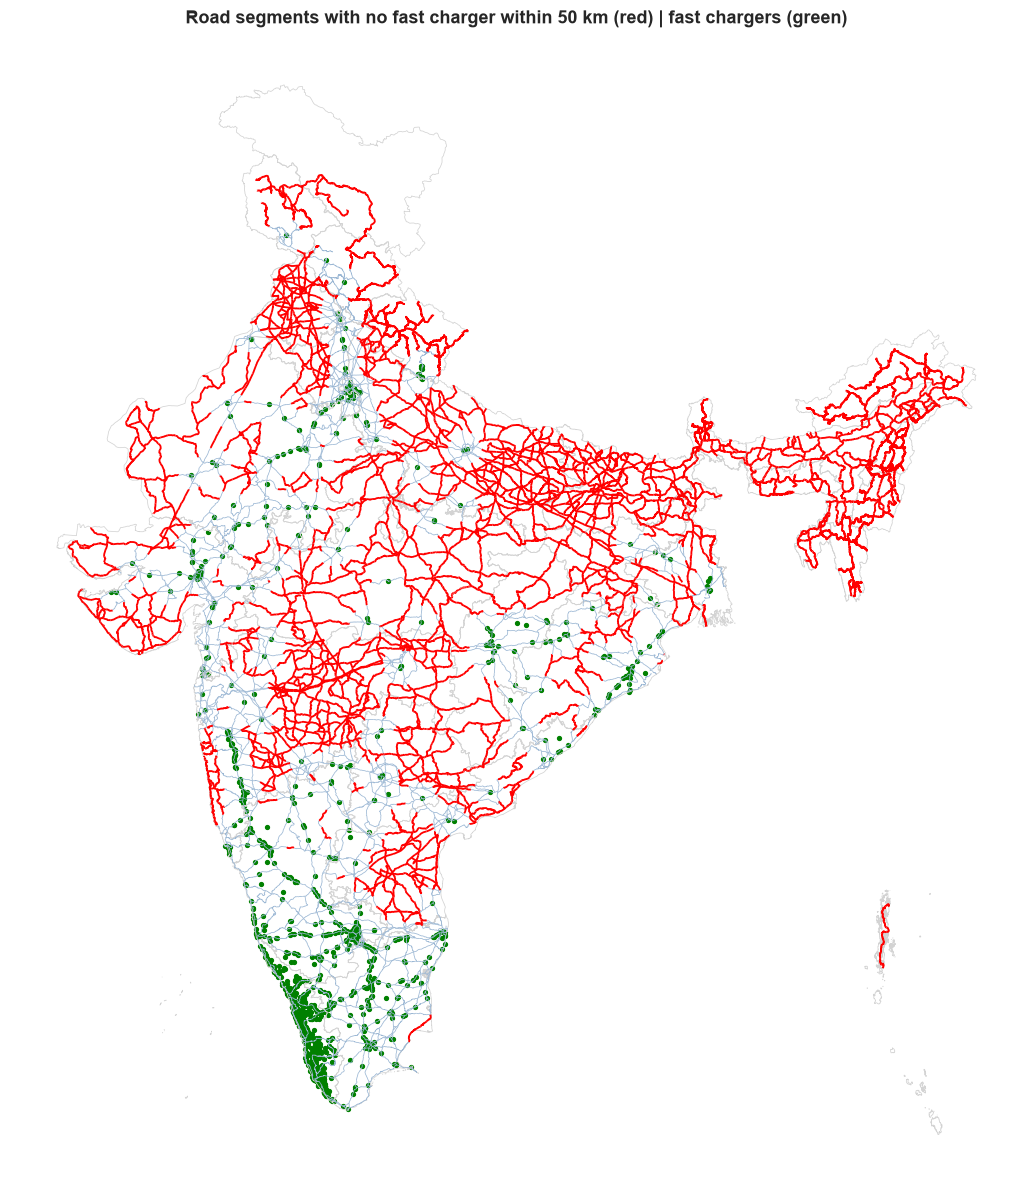

Caution: red in the north and east partly reflects thin OpenChargeMap coverage, not only real gaps.


In [43]:
fig, ax = plt.subplots(figsize=(10, 11))

states_m.boundary.plot(ax=ax, color="lightgrey", linewidth=0.5)
seg_nat[~seg_nat["is_gap"]].plot(ax=ax, color="#9bb7d4", linewidth=0.5)
seg_nat[seg_nat["is_gap"]].plot(ax=ax, color="red", linewidth=1.2)
chargers_gdf[chargers_gdf["is_fast"]].plot(ax=ax, color="green", markersize=6)

ax.set_title(f"Road segments with no fast charger within {GAP_KM} km (red) | fast chargers (green)")
ax.axis("off")
finish("08_national_gap_map")

print("Caution: red in the north and east partly reflects thin OpenChargeMap coverage, not only real gaps.")

# SIX TARGET HIGHWAYS – CLEAN CONTINUOUS LINES

In [44]:
hw6 = hw_all[hw_all["road_name"].isin(TARGET_HIGHWAYS)]

raw_km = highways_gdf[highways_gdf["road_name"].isin(TARGET_HIGHWAYS)].groupby("road_name")["length_km"].sum()

rows = []
for road, group in hw6.groupby("road_name"):
    union_geom = unary_union(group.geometry.values)
    merged = union_geom if union_geom.geom_type == "LineString" else linemerge(union_geom)
    parts = [merged] if merged.geom_type == "LineString" else list(merged.geoms)
    for cid, line in enumerate(parts, start=1):
        rows.append({"road_name": road, "component_id": cid, "length_km": line.length / 1000, "geometry": line})

In [45]:
components = gpd.GeoDataFrame(rows, geometry="geometry", crs=METRIC_CRS)
components["keep"] = components["length_km"] >= MIN_COMPONENT_KM
road_parts = components[components["keep"]].copy()

length_check = pd.DataFrame({
    "raw_summed_km": raw_km,
    "unique_km": components.groupby("road_name")["length_km"].sum(),
    "kept_km": road_parts.groupby("road_name")["length_km"].sum(),
    "pieces_kept": road_parts.groupby("road_name").size()
}).round(1)

display(length_check)

,raw_summed_km,unique_km,kept_km,pieces_kept
road_name,,,,
NH-16,2238.9,1750.0,1711.8,25
NH-44,3967.4,3591.6,3558.1,34
NH-48,2679.8,2555.0,2542.5,24
NH-52,2319.8,2232.4,2228.7,23
NH-544,326.5,330.6,330.6,2
NH-66,2049.0,1711.6,1646.0,43


# CHARGERS WITHIN 5 KM OF EACH HIGHWAY

In [46]:
buffers = road_parts.dissolve(by="road_name")
buffers["geometry"] = buffers.geometry.buffer(CORRIDOR_KM * 1000)
buffers = buffers.reset_index()[["road_name", "geometry"]]

corridor_chargers = gpd.sjoin(chargers_gdf, buffers, predicate="within", how="inner").drop(columns="index_right")
fast_corridor_chargers = corridor_chargers[corridor_chargers["is_fast"]].copy()

In [47]:
cc_stats = corridor_chargers.groupby("road_name").agg(
    all_chargers=("ID", "nunique"),
    fast_chargers=("is_fast", "sum"),
    avg_power_kw=("max_power_kw", "mean")
).round(1)

print("Unique chargers near any target highway:", corridor_chargers["ID"].nunique())
display(cc_stats)

Unique chargers near any target highway: 878


,all_chargers,fast_chargers,avg_power_kw
road_name,,,
NH-16,114,38,19.9
NH-44,213,186,57.4
NH-48,216,191,52.2
NH-52,20,19,48.9
NH-544,109,101,43.5
NH-66,259,243,44.0


# CUT EACH OF THE 6 HIGHWAYS INTO ~25 KM SEGMENTS

In [48]:
seg_rows = []
for _, row in road_parts.iterrows():
    length = row.geometry.length
    n_segments = max(1, int(round(length / (SEG_KM * 1000))))
    step = length / n_segments
    for i in range(n_segments):
        seg = substring(row.geometry, i * step, (i + 1) * step)
        mid = seg.interpolate(0.5, normalized=True)
        seg_rows.append({
            "road_name": row["road_name"],
            "component_id": row["component_id"],
            "segment_id": i + 1,
            "start_km": i * step / 1000,
            "end_km": (i + 1) * step / 1000,
            "length_km": step / 1000,
            "mid_x": mid.x,
            "mid_y": mid.y,
            "geometry": seg
        })

In [49]:
segments = gpd.GeoDataFrame(seg_rows, geometry="geometry", crs=METRIC_CRS)
print("Segments:", len(segments))

display(
    segments.groupby("road_name")["length_km"].agg(["count", "sum", "min", "max"]).round(1)
)

Segments: 519


,count,sum,min,max
road_name,,,,
NH-16,77,1711.8,5.3,31.1
NH-44,149,3558.1,5.1,32.5
NH-48,105,2542.5,5.4,33.3
NH-52,90,2228.7,6.1,36.0
NH-544,14,330.6,23.5,23.7
NH-66,84,1646.0,5.2,31.2


# GAP DETECTION ON THE 6 TARGET HIGHWAYS

In [50]:
def gap_distance(segs, fast_pts):
    """
    Compute distance (km) from each segment midpoint to the nearest fast charger
    that sits on the same highway.
    """
    out = pd.Series(np.inf, index=segs.index)
    for road, idx in segs.groupby("road_name").groups.items():
        pts = fast_pts[fast_pts["road_name"] == road]
        if pts.empty:
            continue
        tree = cKDTree(np.c_[pts.geometry.x, pts.geometry.y])
        d, _ = tree.query(segs.loc[idx, ["mid_x", "mid_y"]].values)
        out.loc[idx] = d / 1000
    return out

In [51]:
# Compute nearest fast charger distance
segments["nearest_fast_km"] = gap_distance(segments, fast_corridor_chargers)
segments["is_gap"] = segments["nearest_fast_km"] > GAP_KM
segments["gap_km"] = segments["length_km"] * segments["is_gap"]

In [52]:
# Assign states to segments
mids6 = gpd.GeoDataFrame(
    segments[["road_name"]],
    geometry=gpd.points_from_xy(segments["mid_x"], segments["mid_y"]),
    crs=METRIC_CRS)

In [53]:
j6 = gpd.sjoin_nearest(mids6, st_small, how="left")
j6 = j6[~j6.index.duplicated()]
segments["state_key"] = j6["state_geo"]
segments["state"] = segments["state_key"].map(key2name)

In [54]:
print("Gap segments:", int(segments["is_gap"].sum()), "of", len(segments),
      "| segments without state:", segments["state"].isna().sum())

Gap segments: 161 of 519 | segments without state: 0


# Q4 – HIGHWAY RELIABILITY SCORECARD

In [55]:
def longest_gap_km(g):
    best = 0
    for _, comp in g.sort_values("start_km").groupby("component_id"):
        cur = 0
        for gap, l in zip(comp["is_gap"], comp["length_km"]):
            cur = cur + l if gap else 0
            best = max(best, cur)
    return best

In [56]:
# Build scorecard
sc = (
    segments.groupby("road_name")
    .apply(lambda g: pd.Series({
        "road_km": g["length_km"].sum(),
        "segments": len(g),
        "gap_segments": int(g["is_gap"].sum()),
        "gap_km": g["gap_km"].sum(),
        "longest_gap_km": longest_gap_km(g)
    }))
    .reset_index()   # <-- ensures road_name is a column
)

In [57]:
# Coverage %
sc["covered_pct"] = 100 * (1 - sc["gap_km"] / sc["road_km"])

In [58]:
# Merge with corridor charger stats
sc = sc.merge(cc_stats.reset_index(), on="road_name", how="left")

In [59]:
# Fill missing values
sc[["all_chargers", "fast_chargers"]] = sc[["all_chargers", "fast_chargers"]].fillna(0)

In [60]:
# Derived metrics
sc["fast_per_100km"] = sc["fast_chargers"] / sc["road_km"] * 100
sc["rating"] = pd.cut(sc["covered_pct"], [-1, 70, 90, 101], labels=["Poor", "Patchy", "Reliable"])

In [61]:
# Sort and clean index
sc = sc.sort_values("covered_pct", ascending=False).reset_index(drop=True).round(1)

In [62]:
# Display
display(sc[["road_name", "road_km", "fast_chargers", "fast_per_100km",
            "covered_pct", "gap_km", "longest_gap_km", "rating"]])
# Export clean CSV
sc.to_csv(OUT / "tables" / "highway_scorecard.csv", index=False)

,road_name,road_km,fast_chargers,fast_per_100km,covered_pct,gap_km,longest_gap_km,rating
0,NH-544,330.6,101,30.6,100.0,0.0,0.0,Reliable
1,NH-48,2542.5,191,7.5,97.7,58.2,27.1,Reliable
2,NH-66,1646.0,243,14.8,70.1,491.8,376.1,Patchy
3,NH-16,1711.8,38,2.2,64.4,609.0,126.2,Poor
4,NH-44,3558.1,186,5.2,56.0,1566.8,426.6,Poor
5,NH-52,2228.7,19,0.9,50.0,1114.7,173.4,Poor


#  Q4 – HIGHWAY RELIABILITY CHARTS

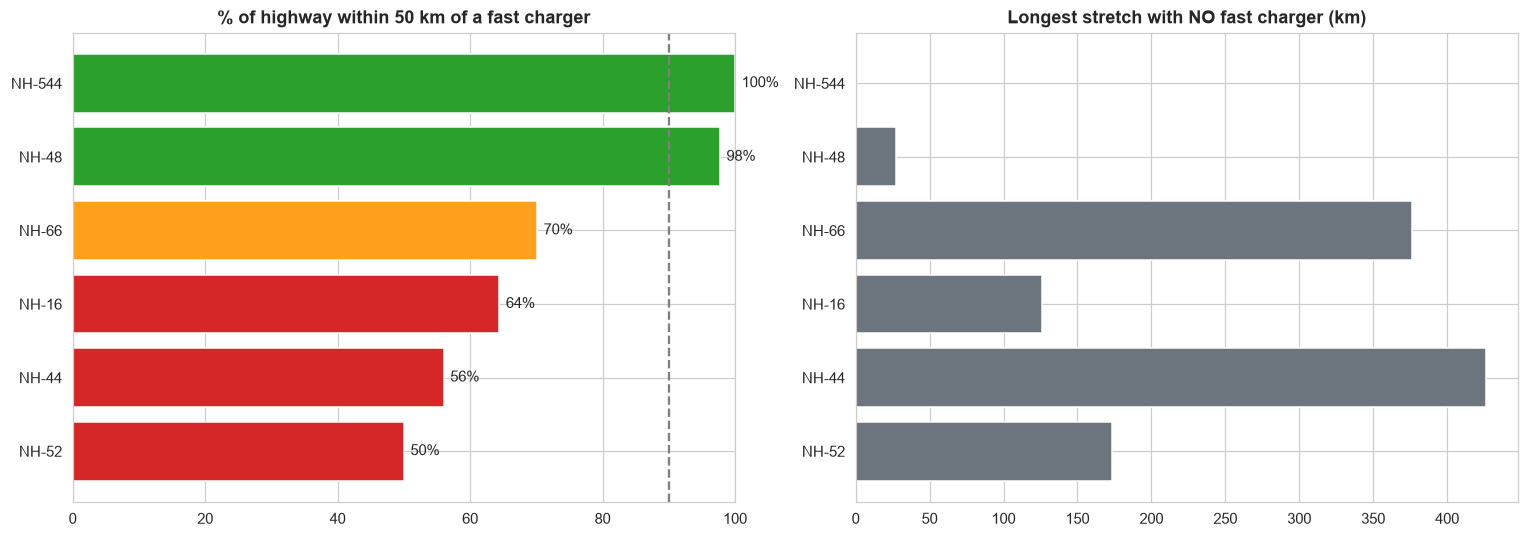

In [63]:
colors = sc["rating"].map({"Reliable": "#2ca02c", "Patchy": "#ff9f1c", "Poor": "#d62728"}).astype(str)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Coverage %
axes[0].barh(sc["road_name"], sc["covered_pct"], color=colors)
axes[0].axvline(90, ls="--", c="grey")
axes[0].set_xlim(0, 100)
for y, v in enumerate(sc["covered_pct"]):
    axes[0].text(v + 1, y, f"{v:.0f}%", va="center")
axes[0].invert_yaxis()
axes[0].set_title(f"% of highway within {GAP_KM} km of a fast charger")

# Longest gaps
axes[1].barh(sc["road_name"], sc["longest_gap_km"], color="#6c757d")
axes[1].invert_yaxis()
axes[1].set_title("Longest stretch with NO fast charger (km)")

finish("09_highway_scorecard")

# Q5 – COVERAGE MAP (Green = covered, Red = gap)

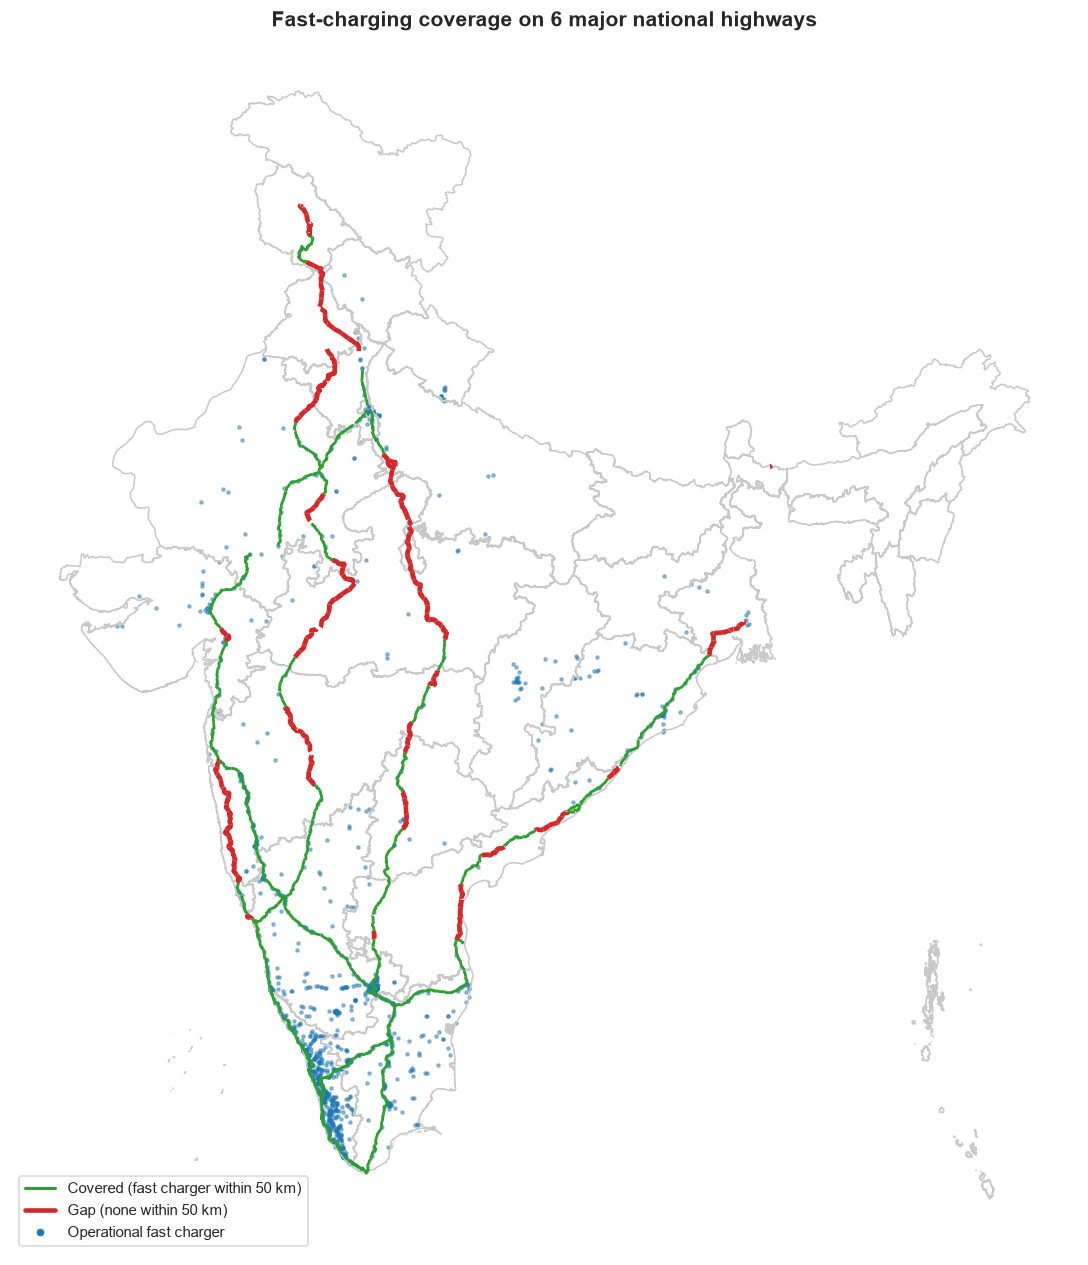

In [64]:
fast_all = chargers_gdf[chargers_gdf["is_fast"]]

fig, ax = plt.subplots(figsize=(10, 12))
states_m.boundary.plot(ax=ax, color="#c8c8c8", linewidth=1.0)
segments[~segments["is_gap"]].plot(ax=ax, color="#2ca02c", linewidth=1.8)
segments[segments["is_gap"]].plot(ax=ax, color="#d62728", linewidth=3)
fast_all.plot(ax=ax, color="#1f77b4", markersize=4, alpha=0.45)

# Legend
ax.legend(handles=[
    Line2D([0], [0], color="#2ca02c", lw=2, label=f"Covered (fast charger within {GAP_KM} km)"),
    Line2D([0], [0], color="#d62728", lw=3, label=f"Gap (none within {GAP_KM} km)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#1f77b4", label="Operational fast charger")
], loc="lower left")

ax.set_axis_off()
ax.set_title("Fast-charging coverage on 6 major national highways", fontsize=14)
finish("10_gap_map_6_highways")

# Q5 – ONE MAP PER HIGHWAY

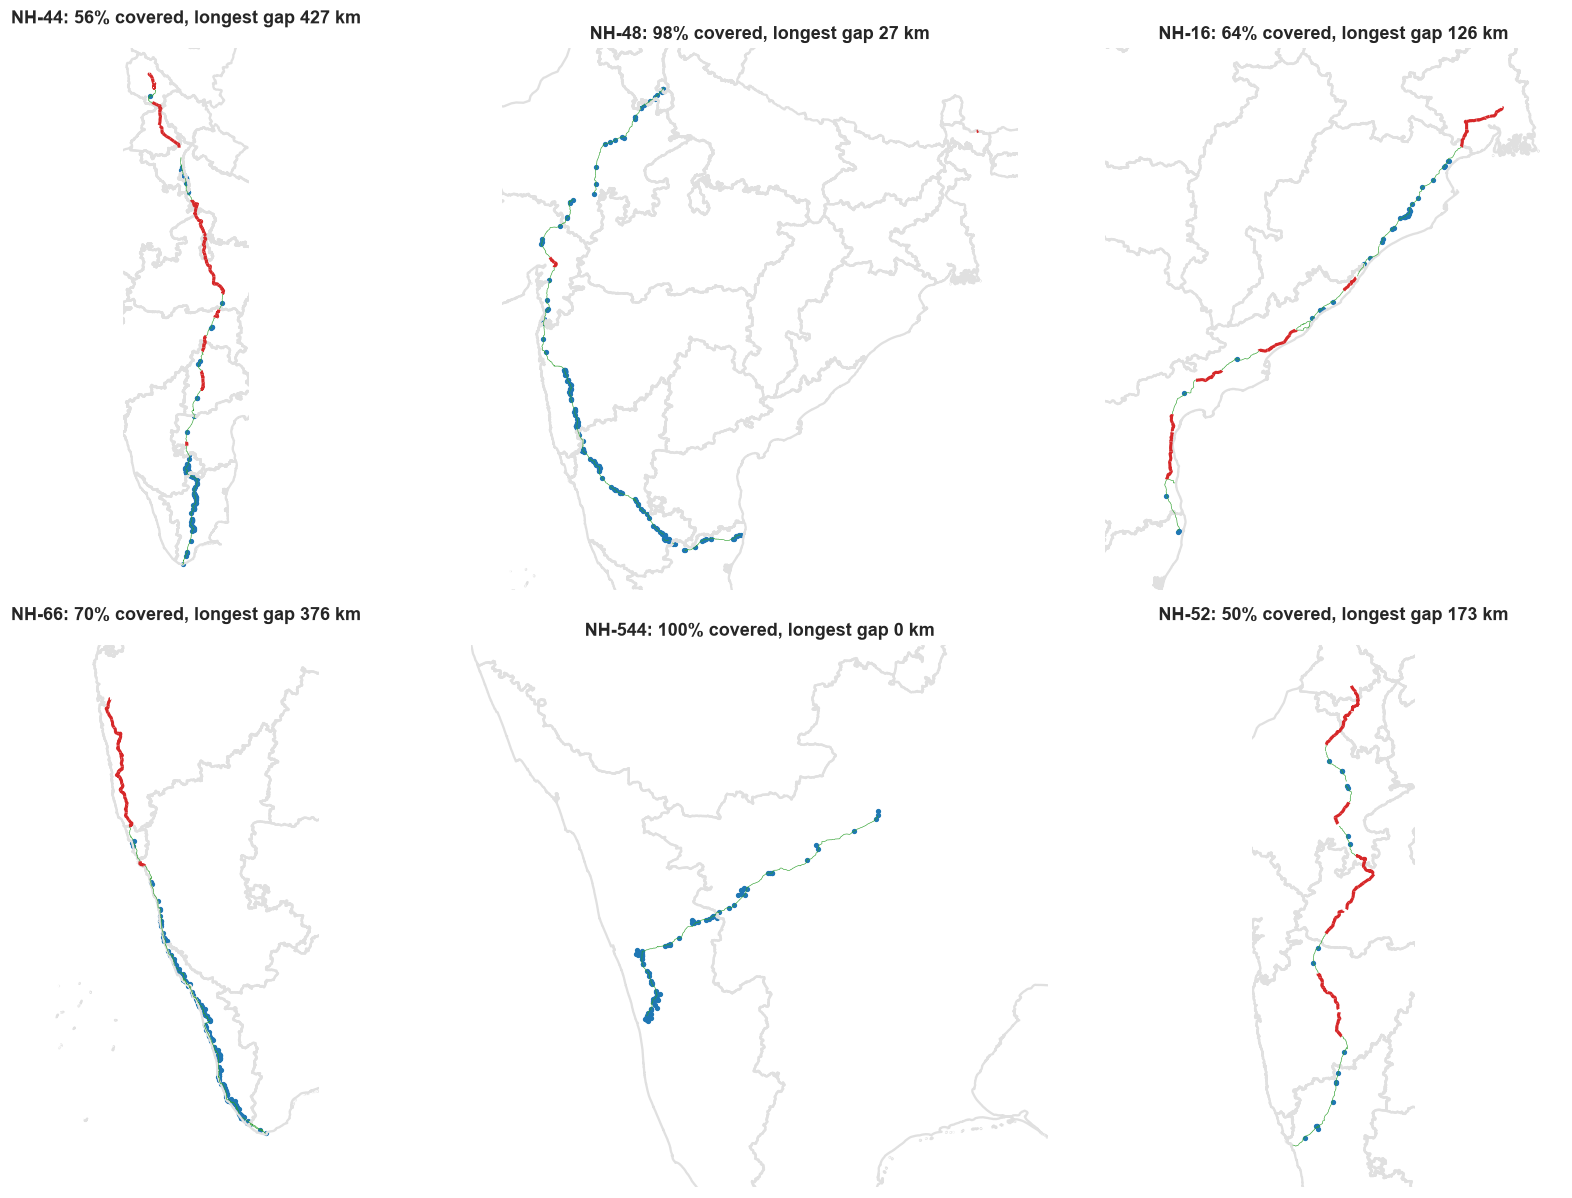

In [65]:
fig, axes = plt.subplots(2, 3, figsize=(16, 11))

for ax, road in zip(axes.ravel(), TARGET_HIGHWAYS):
    s = segments[segments["road_name"] == road]
    states_m.boundary.plot(ax=ax, color="#e0e0e0")
    s[~s["is_gap"]].plot(ax=ax, color="#2ca02c", linewidth=0.4)
    if s["is_gap"].any():
        s[s["is_gap"]].plot(ax=ax, color="#d62728", linewidth=2)
    fast_corridor_chargers[fast_corridor_chargers["road_name"] == road].plot(ax=ax, color="#1f77b4", markersize=6)

    minx, miny, maxx, maxy = s.total_bounds
    pad = 150_000
    ax.set_xlim(minx - pad, maxx + pad)
    ax.set_ylim(miny - pad, maxy + pad)
    ax.set_axis_off()

    row = sc[sc["road_name"] == road].iloc[0]
    ax.set_title(f"{road}: {row['covered_pct']:.0f}% covered, longest gap {row['longest_gap_km']:.0f} km")

finish("11_gap_map_per_highway")

#  Q6 – STATE PRIORITY FOR NEW FAST CHARGERS

In [66]:
state_gap6 = segments.groupby("state").agg(
    highway_km=("length_km", "sum"),
    gap_segments=("is_gap", "sum"),
    gap_km=("gap_km", "sum")
).reset_index()

In [67]:
state_gap6["gap_pct"] = state_gap6["gap_km"] / state_gap6["highway_km"] * 100

priority = (
    state_gap6.merge(master[["state", "hw_ev", "n_fast"]], on="state", how="left")
    .sort_values("gap_km", ascending=False)
    .round(1)
)

In [68]:
display(priority.reset_index(drop=True).head(12))
priority.to_csv(OUT / "tables" / "state_priority_6_highways.csv", index=False)

,state,highway_km,gap_segments,gap_km,gap_pct,hw_ev,n_fast
0,Maharashtra,1833.8,37,891.2,48.6,117168,75.0
1,Madhya Pradesh,895.4,33,795.9,88.9,16643,11.0
2,Andhra Pradesh,1309.4,18,453.3,34.6,20752,14.0
3,Punjab,335.8,13,335.8,100.0,11873,2.0
4,Rajasthan,1306.9,13,327.8,25.1,42182,46.0
5,Uttar Pradesh,314.7,10,248.9,79.1,43468,20.0
6,Jammu and Kashmir,360.0,11,186.4,51.8,1958,1.0
7,West Bengal,186.1,9,186.1,100.0,20032,7.0
8,Telangana,497.8,7,175.2,35.2,60455,10.0
9,Haryana,398.6,7,165.2,41.4,15486,26.0


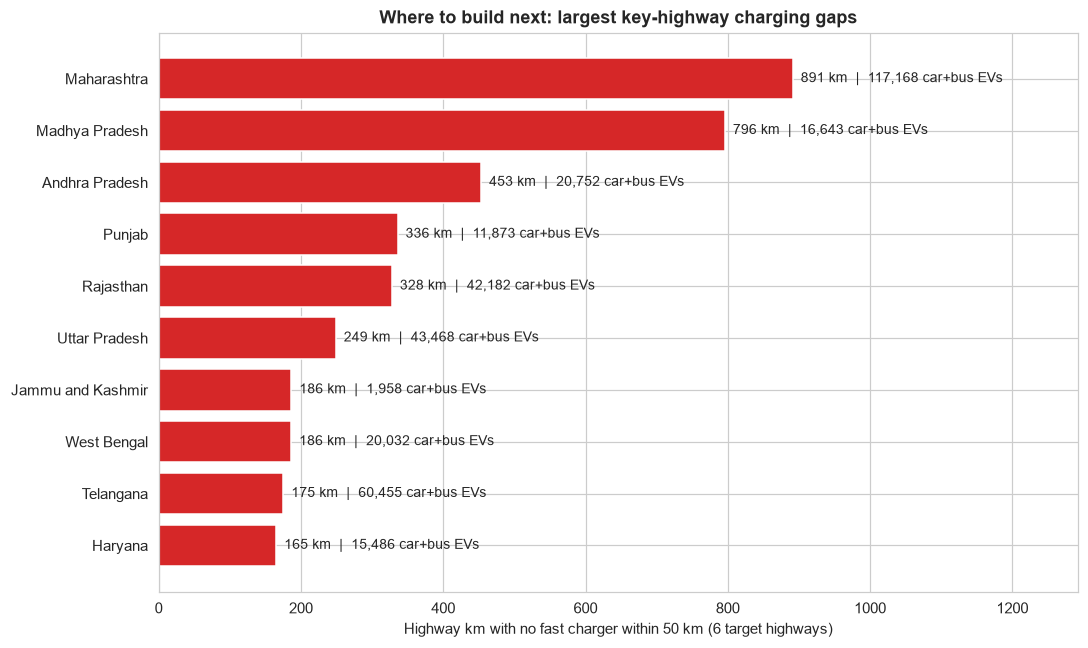

In [69]:
# Plot top 10 uncovered states
p = priority[priority["gap_km"] > 0].head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(p["state"], p["gap_km"], color="#d62728")
for y, (g, e) in enumerate(zip(p["gap_km"], p["hw_ev"])):
    ax.text(g, y, f"  {g:,.0f} km  |  {e:,.0f} car+bus EVs", va="center", fontsize=9)

ax.set_xlabel(f"Highway km with no fast charger within {GAP_KM} km (6 target highways)")
ax.set_title("Where to build next: largest key-highway charging gaps")
ax.set_xlim(0, p["gap_km"].max() * 1.45)
finish("12_state_priority_6_highways")

# Q7 – SENSITIVITY TO GAP DISTANCE RULE

In [70]:
res = {}
for thr in [25, 50, 75, 100]:
    gap = (segments["nearest_fast_km"] > thr) * segments["length_km"]
    res[f"{thr} km"] = 100 * (1 - gap.groupby(segments["road_name"]).sum() /
                              segments.groupby("road_name")["length_km"].sum())

sens = pd.DataFrame(res).round(1)
display(sens)

,25 km,50 km,75 km,100 km
road_name,,,,
NH-16,43.6,64.4,77.5,86.4
NH-44,39.7,56.0,65.9,74.4
NH-48,81.6,97.7,99.7,99.7
NH-52,31.4,50.0,59.0,68.0
NH-544,100.0,100.0,100.0,100.0
NH-66,65.8,70.1,74.6,76.1


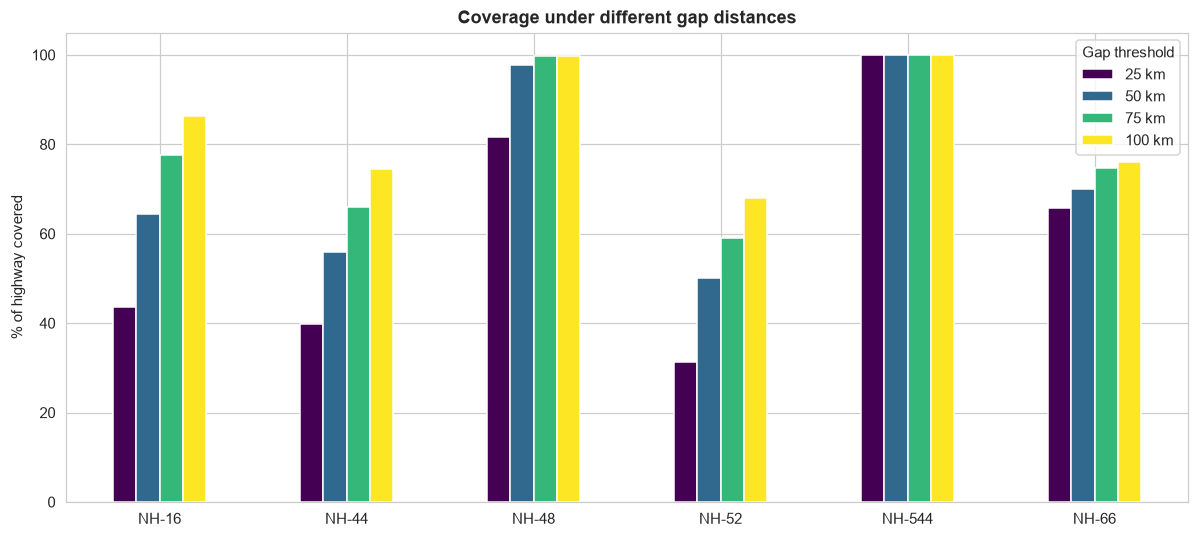

In [71]:
sens.plot(kind="bar", figsize=(11, 5), colormap="viridis")
plt.ylabel("% of highway covered")
plt.xlabel("")
plt.title("Coverage under different gap distances")
plt.xticks(rotation=0)
plt.legend(title="Gap threshold")
finish("13_sensitivity_gap_distance")

# Q7 – FAST CHARGER DEFINITION SENSITIVITY

In [72]:
def coverage_by_road(mask):
    pts = corridor_chargers[mask]
    d = gap_distance(segments, pts)
    gap = (d > GAP_KM) * segments["length_km"]
    return 100 * (1 - gap.groupby(segments["road_name"]).sum() /
                  segments.groupby("road_name")["length_km"].sum())

In [73]:
defs = {
    "power >= 22 kW": corridor_chargers["max_power_kw"] >= 22,
    "power >= 25 kW": corridor_chargers["max_power_kw"] >= 25,
    "power >= 50 kW": corridor_chargers["max_power_kw"] >= 50,
    "dataset flag": corridor_chargers["has_fast_charging"].astype(bool)
}

In [74]:
sens2 = pd.DataFrame({name: coverage_by_road(m) for name, m in defs.items()}).round(1)
display(sens2)

,power >= 22 kW,power >= 25 kW,power >= 50 kW,dataset flag
road_name,,,,
NH-16,64.4,64.4,33.3,24.2
NH-44,56.0,56.0,48.0,56.0
NH-48,97.7,97.7,81.7,95.6
NH-52,50.0,50.0,28.9,50.0
NH-544,100.0,100.0,100.0,100.0
NH-66,70.1,70.1,70.1,70.1


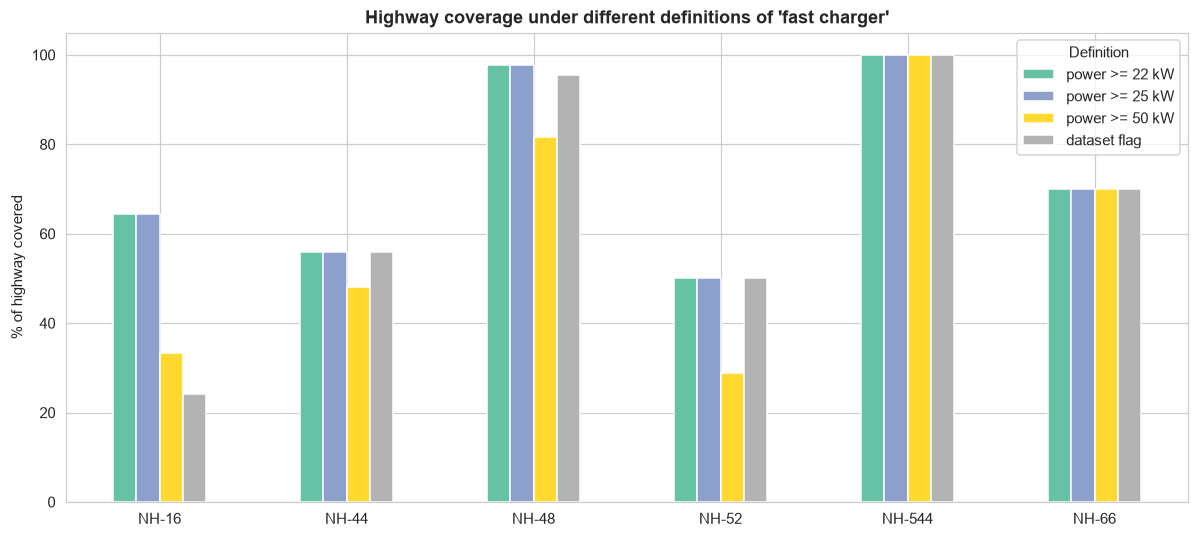

In [75]:
sens2.plot(kind="bar", figsize=(11, 5), colormap="Set2")
plt.ylabel("% of highway covered")
plt.xlabel("")
plt.xticks(rotation=0)
plt.title("Highway coverage under different definitions of 'fast charger'")
plt.legend(title="Definition")
finish("14_sensitivity_fast_definition")

In [76]:
# RATING UNDER EACH DEFINITION 
def rate(s):
    
    return pd.cut(s, [-1, 70, 90, 101], labels=["Poor", "Patchy", "Reliable"]).astype(str)

rating_tbl = sens2.apply(rate)
core = ["power >= 25 kW", "dataset flag"]                      # the two realistic definitions
rating_tbl["verdict"] = np.where(rating_tbl[core].nunique(axis=1) == 1,
                                 "Stable rating", "Depends on definition")
rating_tbl["coverage_range_%"] = (sens2.min(axis=1).round(0).astype(int).astype(str) + " - "
                                  + sens2.max(axis=1).round(0).astype(int).astype(str))
display(rating_tbl)
rating_tbl.to_csv(OUT / "tables" / "highway_rating_by_definition.csv")

,power >= 22 kW,power >= 25 kW,power >= 50 kW,dataset flag,verdict,coverage_range_%
road_name,,,,,,
NH-16,Poor,Poor,Poor,Poor,Stable rating,24 - 64
NH-44,Poor,Poor,Poor,Poor,Stable rating,48 - 56
NH-48,Reliable,Reliable,Patchy,Reliable,Stable rating,82 - 98
NH-52,Poor,Poor,Poor,Poor,Stable rating,29 - 50
NH-544,Reliable,Reliable,Reliable,Reliable,Stable rating,100 - 100
NH-66,Patchy,Patchy,Patchy,Patchy,Stable rating,70 - 70


# ADD HIGHWAY METRICS TO STATE MASTER TABLE

In [77]:
hwy = seg_nat.groupby("state_key").agg(
    hwy_km=("seg_km", "sum"),
    gap_km=("gap_km", "sum")
).reset_index()

corr = chargers_gdf.groupby("state_geo")["on_corridor"].sum().rename("n_on_corridor").reset_index()
corr = corr.rename(columns={"state_geo": "state_key"})

In [78]:
master = (
    master.drop(columns=["hwy_km", "gap_km", "n_on_corridor"], errors="ignore")
    .merge(hwy, on="state_key", how="left")
    .merge(corr, on="state_key", how="left")
)

master[["hwy_km", "gap_km", "n_on_corridor"]] = master[["hwy_km", "gap_km", "n_on_corridor"]].fillna(0)
master["fast_per_1000_hwy_km"] = np.where(master["hwy_km"] > 0, master["n_fast"] / master["hwy_km"] * 1000, np.nan)
master["pct_hwy_gap"] = np.where(master["hwy_km"] > 0, master["gap_km"] / master["hwy_km"] * 100, np.nan)

In [79]:
print("States with no highway in the data:", master.loc[master["hwy_km"] == 0, "state"].tolist())
display(master.sort_values("ev_total", ascending=False).reset_index(drop=True)
.head(10)[
    ["state", "ev_total", "n_chargers", "n_fast", "hwy_km", "gap_km", "pct_hwy_gap"]
])

States with no highway in the data: ['Chandigarh', 'Lakshadweep']


,state,ev_total,n_chargers,n_fast,hwy_km,gap_km,pct_hwy_gap
0,Uttar Pradesh,1815492,28.0,20.0,15135.034570,11546.006248,76.286620
1,Maharashtra,1170473,83.0,75.0,20421.393780,12933.476949,63.332979
2,Karnataka,912484,376.0,323.0,8133.700981,205.194170,2.522765
3,Tamil Nadu,708760,212.0,181.0,7767.455336,154.961173,1.995006
4,Rajasthan,569096,47.0,46.0,11810.818158,5324.898092,45.084921
5,Bihar,560438,1.0,0.0,6739.936650,6739.936650,100.000000
6,Delhi,515897,34.0,17.0,244.067473,0.000000,0.000000
7,Madhya Pradesh,513003,13.0,11.0,11169.005208,8781.682204,78.625464
8,Kerala,433492,587.0,544.0,2245.258984,0.000000,0.000000
9,Gujarat,415842,67.0,36.0,8850.324493,3869.317529,43.719499


# STATE EDA – TOP STATES + CORRELATION

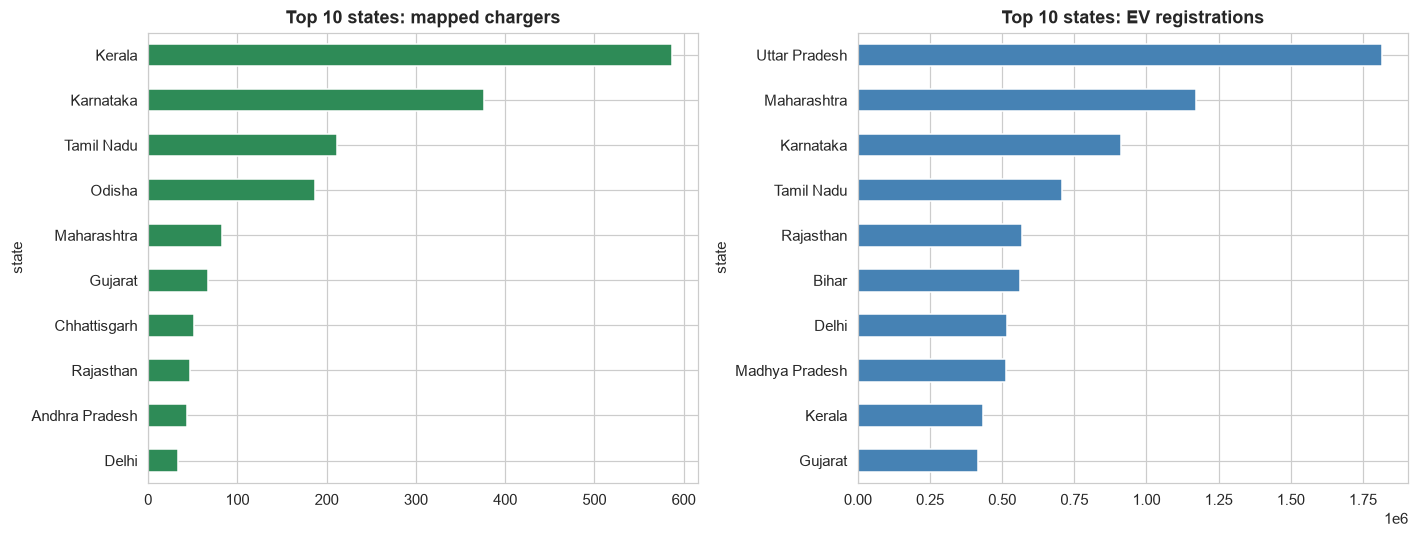

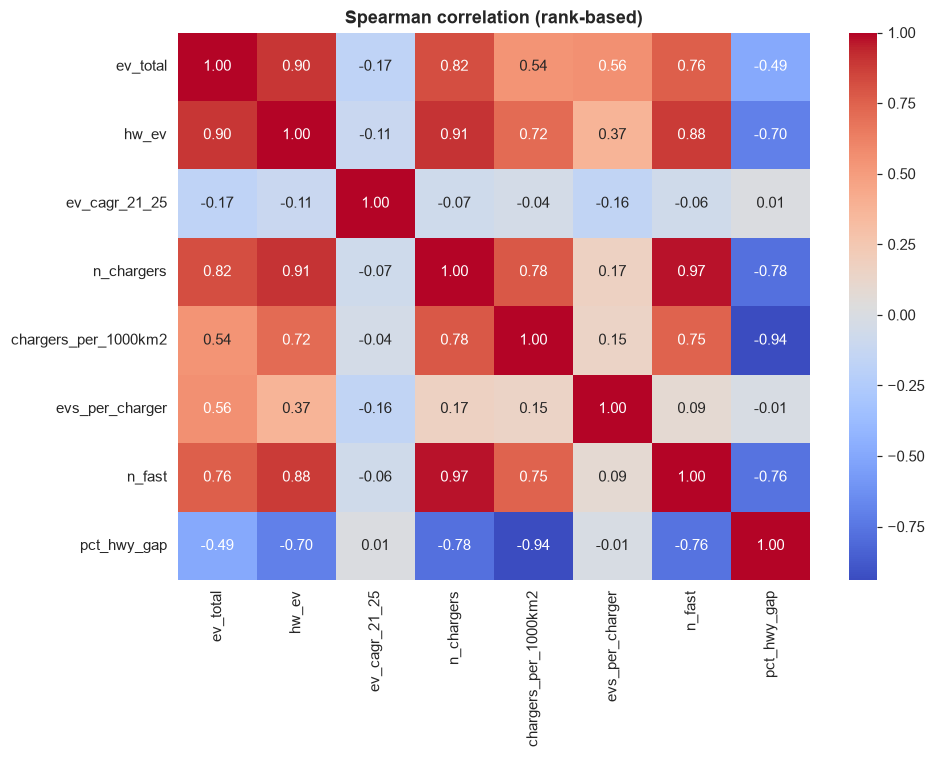

In [80]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

master.nlargest(10, "n_chargers").plot.barh(x="state", y="n_chargers", ax=ax[0], legend=False, color="seagreen")
ax[0].set_title("Top 10 states: mapped chargers")
ax[0].invert_yaxis()

master.nlargest(10, "ev_total").plot.barh(x="state", y="ev_total", ax=ax[1], legend=False, color="steelblue")
ax[1].set_title("Top 10 states: EV registrations")
ax[1].invert_yaxis()

finish("15_top_states_chargers_vs_evs")

# Correlation heatmap
num_cols = ["ev_total", "hw_ev", "ev_cagr_21_25", "n_chargers", "chargers_per_1000km2",
            "evs_per_charger", "n_fast", "pct_hwy_gap"]

plt.figure(figsize=(9, 7))
sns.heatmap(master[num_cols].corr(method="spearman"), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Spearman correlation (rank-based)")
finish("16_spearman_heatmap")

# ADVANCED – STATE GAP SCORE ("EV Desert Index")

In [81]:
def minmax(s):
    s = s.astype(float)
    return (s - s.min()) / (s.max() - s.min()) if s.max() > s.min() else s * 0

g = master.copy()
g["pct_hwy_gap"] = g["pct_hwy_gap"].fillna(g["pct_hwy_gap"].median())

g["n_demand"] = minmax(np.log1p(g["evs_per_charger"]))          # more EVs per charger = worse
g["n_hwygap"] = minmax(g["pct_hwy_gap"])                       # more uncovered highway = worse
g["n_density"] = minmax(np.log1p(g["chargers_per_1000km2"]))   # sparse chargers = worse

W = {"n_demand": 0.40, "n_hwygap": 0.35, "n_density": 0.25}

g[list(W)] = g[list(W)].replace([np.inf, -np.inf], np.nan).fillna(0)
g["gap_score"] = 100 * sum(g[k] * w for k, w in W.items())
g["gap_rank"] = g["gap_score"].rank(ascending=False, method="min").astype(int)
g["gap_class"] = pd.qcut(g["gap_score"], q=3, labels=["Low gap", "Medium gap", "High gap"])

master = g

display(master.sort_values("gap_score", ascending=False)[
    ["state", "ev_total", "n_chargers", "evs_per_charger", "pct_hwy_gap", "gap_score", "gap_class"]
].reset_index(drop=True).head(15))


,state,ev_total,n_chargers,evs_per_charger,pct_hwy_gap,gap_score,gap_class
0,Bihar,560438,1.0,560438.000000,100.000000,75.085616,High gap
1,Chandigarh,27419,1.0,27419.000000,72.201918,70.913901,High gap
2,Assam,384300,2.0,192150.000000,100.000000,70.850359,High gap
3,Tripura,45221,0.0,45221.000000,100.000000,64.762825,High gap
4,Punjab,181928,2.0,90964.000000,85.718567,62.917898,High gap
5,Uttar Pradesh,1815492,28.0,64839.000000,76.286620,58.815899,High gap
6,Madhya Pradesh,513003,13.0,39461.769231,78.625464,57.062434,High gap
7,West Bengal,341644,9.0,37960.444444,75.395582,56.249295,High gap
8,Jharkhand,139850,6.0,23308.333333,79.838222,55.597794,High gap
9,Manipur,4115,0.0,4115.000000,100.000000,55.015457,High gap


# ADVANCED – K-MEANS CLUSTERING

In [82]:
X = StandardScaler().fit_transform(master[["n_demand", "n_hwygap", "n_density"]])
master["cluster"] = KMeans(n_clusters=3, n_init=10, random_state=42).fit_predict(X)

prof = master.groupby("cluster")[["gap_score", "ev_total", "n_chargers"]].mean().round(1)
prof["states"] = master.groupby("cluster").size()
display(prof)

,gap_score,ev_total,n_chargers,states
cluster,,,,
0,52.4,408848.8,23.0,18
1,37.9,334214.2,156.4,9
2,44.5,1179.3,0.0,9


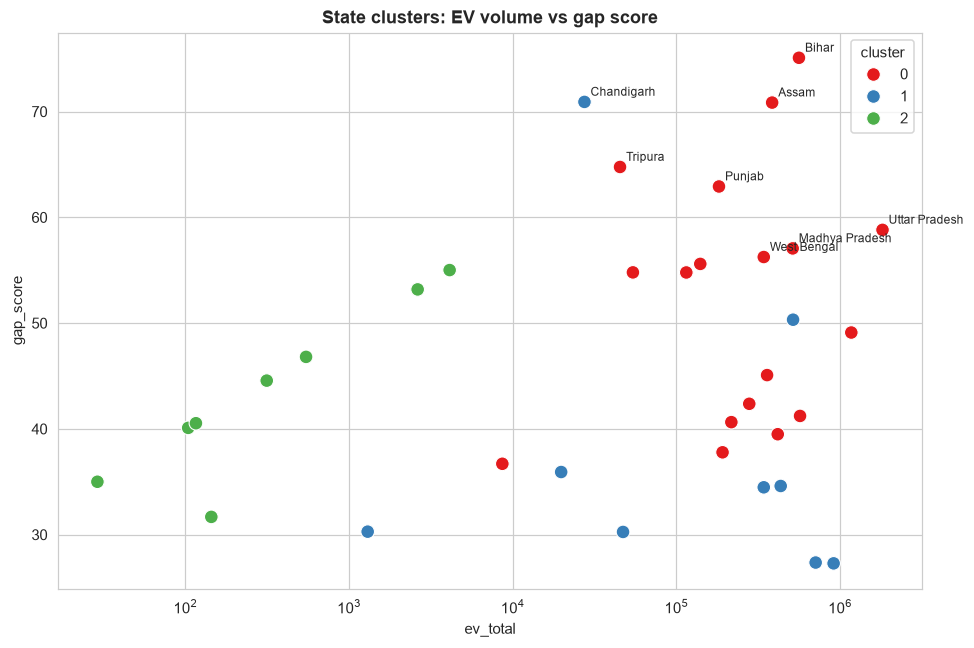

In [83]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=master, x="ev_total", y="gap_score", hue="cluster", palette="Set1", s=80)
for _, r in master.nlargest(8, "gap_score").iterrows():
    plt.annotate(r["state"], (r["ev_total"], r["gap_score"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
plt.xscale("log")
plt.title("State clusters: EV volume vs gap score")
finish("17_state_clusters")

# ADVANCED – STABILITY OF WEIGHT CHOICES

In [84]:
scen = {
    "base 0.40/0.35/0.25": (0.40, 0.35, 0.25),
    "equal weights": (1/3, 1/3, 1/3),
    "demand-heavy": (0.6, 0.2, 0.2),
    "highway-heavy": (0.2, 0.6, 0.2),
    "density-heavy": (0.2, 0.2, 0.6)
}

base_top = set(master.nlargest(10, "gap_score")["state"])
base_rank = master["gap_score"].rank(ascending=False)

In [85]:
rows = []
for name, (a, b, c_) in scen.items():
    s = 100 * (a * master["n_demand"] + b * master["n_hwygap"] + c_ * master["n_density"])
    rows.append({
        "scenario": name,
        "top10_overlap": len(base_top & set(master.assign(s=s).nlargest(10, "s")["state"])),
        "rank_correlation": round(base_rank.corr(s.rank(ascending=False), method="spearman"), 3)
    })

In [86]:
# Alternative demand definition: cars+buses per fast charger
alt_d = minmax(np.log1p(master["evs_per_fast_charger"]))
s = 100 * (0.40 * alt_d + 0.35 * master["n_hwygap"] + 0.25 * master["n_density"])
rows.append({
    "scenario": "demand = cars+buses per fast charger",
    "top10_overlap": len(base_top & set(master.assign(s=s).nlargest(10, "s")["state"])),
    "rank_correlation": round(base_rank.corr(s.rank(ascending=False), method="spearman"), 3)
})

display(pd.DataFrame(rows))

,scenario,top10_overlap,rank_correlation
0,base 0.40/0.35/0.25,10,1.000
1,equal weights,8,0.964
2,demand-heavy,8,0.885
3,highway-heavy,6,0.816
4,density-heavy,5,0.446
5,demand = cars+buses per fast charger,8,0.896


# WHERE IS THE OVERALL GAP BIGGEST?

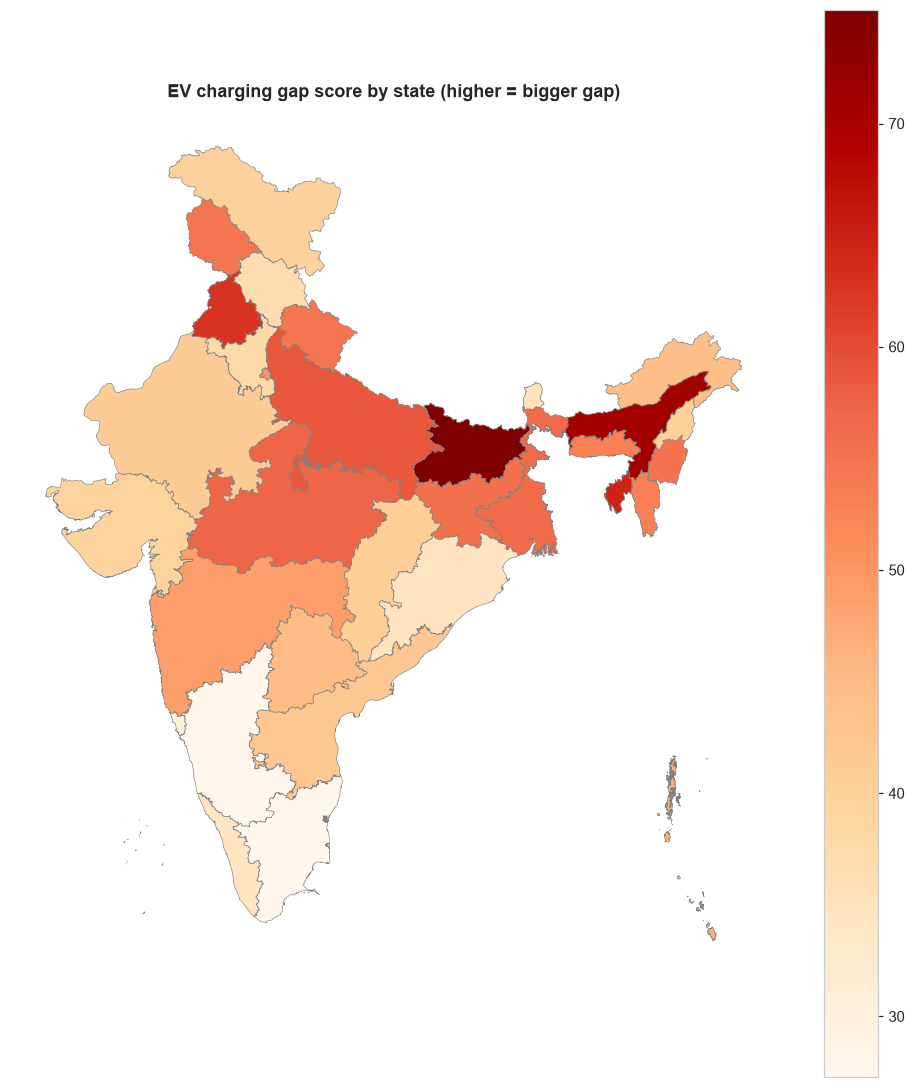

In [87]:
choro = states_m.merge(master[["state_key", "gap_score", "gap_class"]], on="state_key", how="left")

fig, ax = plt.subplots(figsize=(9, 10))
choro.plot(column="gap_score", cmap="OrRd", legend=True, edgecolor="grey", linewidth=0.4,
           missing_kwds={"color": "lightgrey"}, ax=ax)
ax.set_title("EV charging gap score by state (higher = bigger gap)")
ax.axis("off")
finish("18_gap_score_map")

# TOP 10 STATES BY GAP SCORE

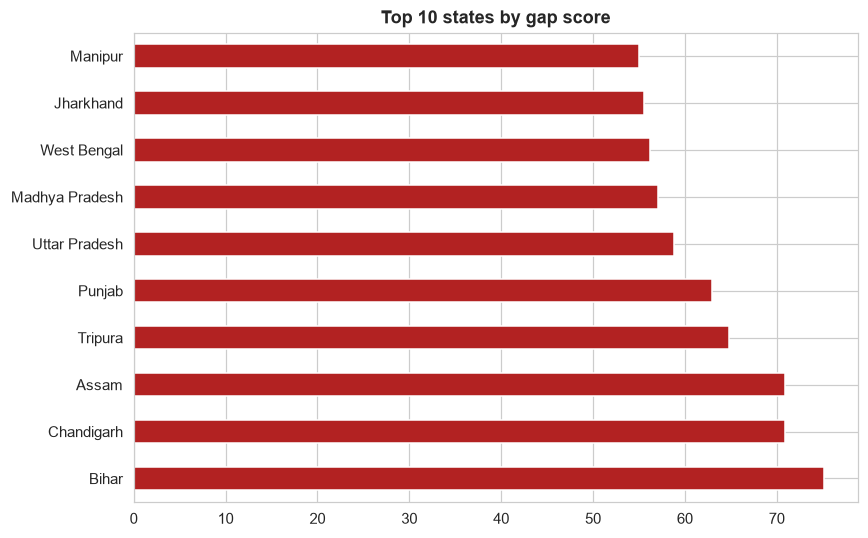

In [110]:
master.nlargest(10, "gap_score").plot.barh(
    x="state", y="gap_score", figsize=(8, 5), legend=False, color="firebrick"
)
plt.title("Top 10 states by gap score")
plt.ylabel("")
finish("19_top10_gap_score")

# STATE GAP SCORE vs KEY-HIGHWAY GAP

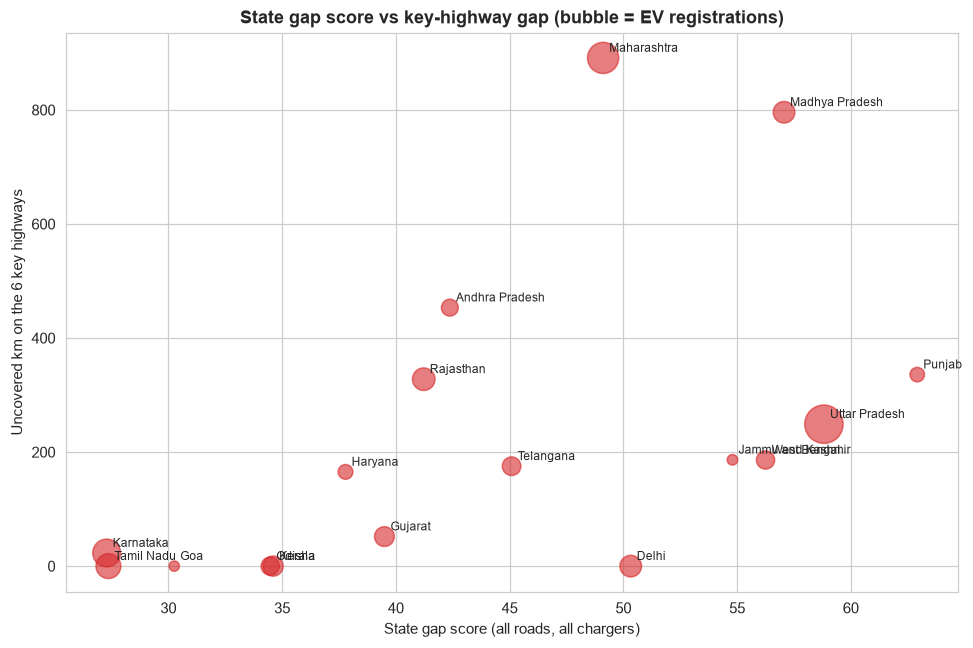

In [89]:
x = master[["state", "gap_score", "ev_total"]].merge(priority[["state", "gap_km"]], on="state", how="inner")

plt.figure(figsize=(9, 6))
plt.scatter(x["gap_score"], x["gap_km"], s=x["ev_total"] / x["ev_total"].max() * 600 + 30,
            alpha=0.6, color="#d62728")

for _, r in x.iterrows():
    plt.annotate(r["state"], (r["gap_score"], r["gap_km"]), fontsize=8, xytext=(4, 4), textcoords="offset points")

plt.xlabel("State gap score (all roads, all chargers)")
plt.ylabel("Uncovered km on the 6 key highways")
plt.title("State gap score vs key-highway gap (bubble = EV registrations)")
finish("20_score_vs_corridor_gap")

# KEY FINDINGS

In [90]:
top5 = master.nlargest(5, "gap_score")["state"].tolist()
best, worst = sc.iloc[0], sc.iloc[-1]
longest = sc.sort_values("longest_gap_km", ascending=False).iloc[0]
nat_gap = seg_nat["gap_km"].sum()
deserts = master[master["hw_ev"] >= MIN_DEMAND].nlargest(3, "evs_per_fast_charger")["state"].tolist()
zero = master.loc[master["n_chargers"] == 0, "state"].tolist()

In [91]:
print("KEY FINDINGS")
print(f"1. EV fleet: {int(ev_all['Total'].sum()):,} registrations; only "
      f"{(ev_car['Total'].sum() + ev_bus['Total'].sum()) / ev_all['Total'].sum():.0%} are cars/buses.")
print(f"2. Mapped operational chargers: {len(chargers_gdf):,}; fast (>= {FAST_KW} kW): {int(chargers_gdf['is_fast'].sum()):,}.")
print(f"3. {nat_gap:,.0f} km of the road network "
      f"({nat_gap/seg_nat['seg_km'].sum():.0%}) has no fast charger within {GAP_KM} km.")
print(f"4. Best-covered key highway: {best['road_name']} ({best['covered_pct']:.0f}%). Worst: {worst['road_name']} ({worst['covered_pct']:.0f}%).")
print(f"5. Longest key-highway stretch with no fast charger: {longest['longest_gap_km']:.0f} km on {longest['road_name']}.")
print(f"6. Largest key-highway gap: {priority.iloc[0]['state']} ({priority.iloc[0]['gap_km']:.0f} km uncovered).")
print(f"7. Highest overall gap scores: {', '.join(top5)}.")
print(f"8. Biggest EV deserts (cars+buses per fast charger): {', '.join(deserts)}.")
print(f"9. States with zero mapped chargers: {', '.join(zero) or 'none'}.")
print(f"10. {chargers_gdf['on_corridor'].mean():.0%} of operational chargers are within {CORRIDOR_KM} km of a mapped highway.")

KEY FINDINGS
1. EV fleet: 10,377,820 registrations; only 7% are cars/buses.
2. Mapped operational chargers: 1,822; fast (>= 25 kW): 1,421.
3. 98,551 km of the road network (60%) has no fast charger within 50 km.
4. Best-covered key highway: NH-544 (100%). Worst: NH-52 (50%).
5. Longest key-highway stretch with no fast charger: 427 km on NH-44.
6. Largest key-highway gap: Maharashtra (891 km uncovered).
7. Highest overall gap scores: Bihar, Chandigarh, Assam, Tripura, Punjab.
8. Biggest EV deserts (cars+buses per fast charger): Telangana, Punjab, Delhi.
9. States with zero mapped chargers: Andaman and Nicobar Islands, Arunachal Pradesh, Ladakh, Lakshadweep, Manipur, Meghalaya, Mizoram, Nagaland, Sikkim, Tripura.
10. 86% of operational chargers are within 5 km of a mapped highway.


In [92]:
# Export tables
master.drop(columns=["cluster"], errors="ignore").to_csv(OUT / "tables" / "state_gap_master.csv", index=False)
seg_nat.to_crs(4326).to_file(OUT / "tables" / "national_segments_gap.geojson", driver="GeoJSON")
segments.drop(columns=["mid_x", "mid_y"]).to_crs(4326).to_file(OUT / "tables" / "segments_6_highways_gap.geojson", driver="GeoJSON")
chargers_gdf.to_crs(4326).drop(columns=["date_created", "date_last_verified"], errors="ignore") \
    .to_file(OUT / "tables" / "chargers_clean.geojson", driver="GeoJSON")

print("\nSaved outputs to:", OUT.resolve())


Saved outputs to: C:\Users\INBA\Desktop\OneDrive - ELCOT\Inba\Anudip\Project\EV_Highway_Corridor_Reliability_Gap_Analysis\outputs
